# Michaelis-Menten model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## We consider (a) the full MM model and (b) its approximation

In [2]:
def modelMM(t, state, k1=1, k_1=1, k2=1):

    s, e, c, p = state # concentrations of substrate, enzyme, complex (ES), product, respectively

    dsdt = -k1*e*s + k_1*c # rate of change of substrate
    dedt = -k1*e*s + (k_1 + k2)*c # etc
    dcdt =  k1*e*s - (k_1 + k2)*c
    dpdt =  k2*c

    return (dsdt, dedt, dcdt, dpdt)

def modelMM_approximate(t, state, Vmax=1, K=1):

    s, p = state

    dsdt = -Vmax*s / (K + s)

    dpdt = Vmax*s / (K + s)

    return (dsdt, dpdt)

## Parameters and initial condition

In [3]:
k1=1
k_1=1
k2=1

t_0 = 0
t_max = 30

state_initial = (10, 1, 0, 0) # At t=0, concentrations S=10, E=1, C=0, P=0

### Michaelis-Menten model -- Figure 1.3-$left$

In [4]:
solution = solve_ivp(modelMM, [t_0, t_max], state_initial, args=(k1, k_1, k2), max_step=0.1)

#### Show evolution of concentrations

Text(0, 0.5, 'Concentration')

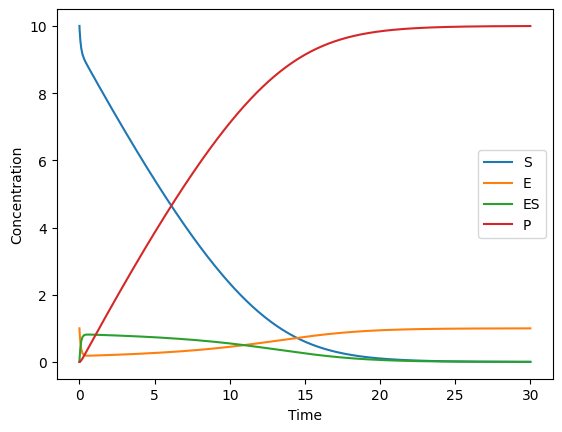

In [5]:
labels = ['S', 'E', 'ES', 'P']

for lbl, vec in zip(labels, solution.y):

    plt.plot(solution.t, vec, label=lbl)

plt.legend()

plt.xlabel('Time')
plt.ylabel('Concentration')

### Approximation to the Michaelis-Menten model -- Figure 1.3-$right$

In [6]:
Vmax = k2 * state_initial[1]
K = (k_1 + k2) / k1

state_initial_approx = (state_initial[0], state_initial[-1]) # At t=0, concentrations S=10, P=0
solution_approx = solve_ivp(modelMM_approximate, [t_0, t_max],
                            state_initial_approx, args=(Vmax, K), max_step=0.1)

#### Show evolution of concentrations

Text(0, 0.5, 'Concentration')

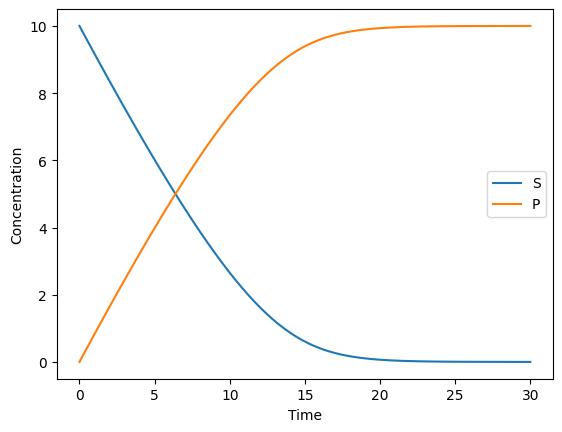

In [7]:
labels_approx = ['S','P']

for lbl, vec in zip(labels_approx, solution_approx.y):

    plt.plot(solution_approx.t, vec, label=lbl)

plt.legend()

plt.xlabel('Time')
plt.ylabel('Concentration')

## Bonus: Compare solutions of the MM model and its approximation

Text(0.5, 1.0, 'Product')

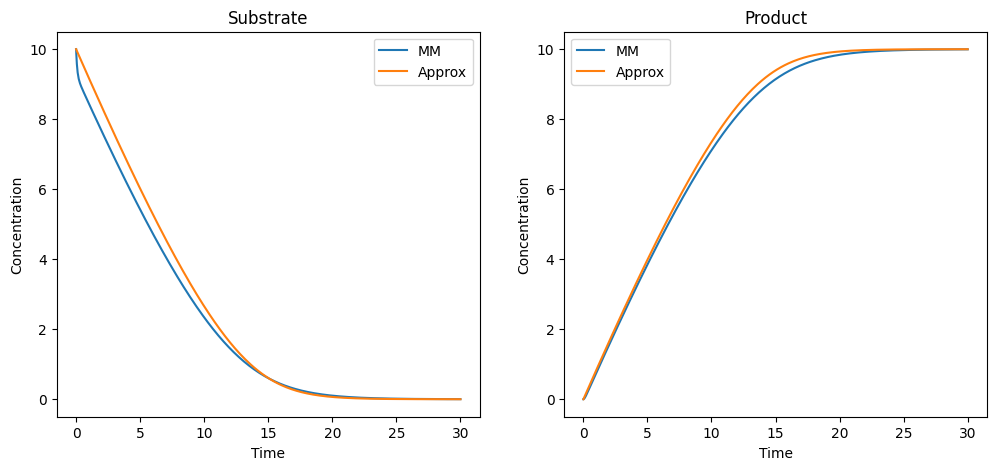

In [8]:
f, (ax_s, ax_p) = plt.subplots(1,2, figsize=(12,5))

## Subplot for Substrate
ax_s.plot(solution.t, solution.y[0], label='MM')
ax_s.plot(solution_approx.t, solution_approx.y[0], label='Approx')
ax_s.legend()
ax_s.set_xlabel('Time')
ax_s.set_ylabel('Concentration')
ax_s.set_title('Substrate')


## Subplot for Product
ax_p.plot(solution.t, solution.y[-1], label='MM')
ax_p.plot(solution_approx.t, solution_approx.y[-1], label='Approx')
ax_p.legend()
ax_p.set_xlabel('Time')
ax_p.set_ylabel('Concentration')
ax_p.set_title('Product')

Although the Appxoximation model (Approx) follows the original Michaelis Menten (MM) model, we can see differences. The Approximation model  overestimates the subtstrate concentration between time = 0...~15, and underestimates it at later times. The Approximation model overestimates the Product concentration at most of the times.

## Hill equation -- Figure 1.4

Text(0.5, 1.0, "Hill's equation")

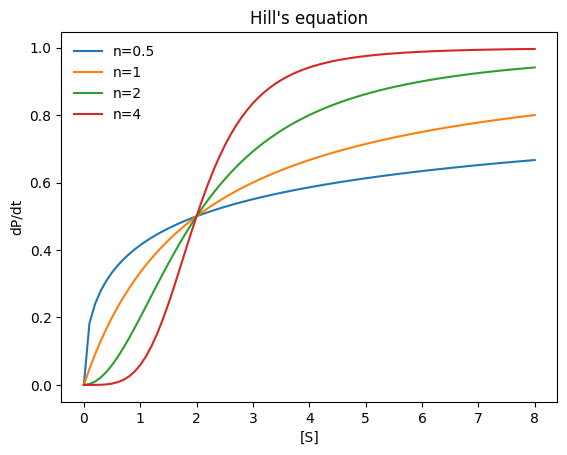

In [9]:
for n in [0.5, 1, 2, 4]:
    SS = np.arange(0, 8.1, 0.1)
    PP = (Vmax*SS**n) / (K**n + SS**n);

    plt.plot(SS, PP, label=f"n={n}")

plt.legend(frameon=False)

plt.xlabel('[S]')
plt.ylabel('dP/dt')
plt.title("Hill's equation")